## Comparing the FS and RS AdEx models, and NP 3varAdEx using Brian2

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

This notebook presents a comparison between three different models: Fast Spiking (FS) and Regular Spiking (RS) *AdEx* models and the Impaired neuron model (IMP) implemented with the *3varAdEx* published in [Depannemaecker et al., 2025](https://link.springer.com/article/10.1007/s10827-025-00893-7). 

The **classical AdEx** describes the evolution of the membrane potential $V(t)$ of a single compartment of a neuron membrane. It consists of a system of *two differential equations*:
\begin{align}
    \left\{
    \begin{array}{l}
        C \dfrac{dV}{dt} = -g_{L} (V - E_L) + g_L \Delta_T \exp \left( \dfrac{V - V_\textit{th}}{\Delta_T} \right) - w + I \\
        \tau_w \dfrac{dw}{dt} = a \left( V - E_L \right) - w
    \end{array}
    \right.
\end{align}
When the potential goes beyond ${V}_\textit{th}$, the exponential term generates an upswing of the membrane potential that mimics the exponential activation of $\textrm{\textit{Na}}^+$ channels in a Hodgkin–Huxley-type neuron model, leading to the initiation of an action potential. At a spike detection threshold (e.g. 0 mV), a series of reset conditions is triggered:
\begin{align}
    \left\{
    \begin{array}{l}
        V \rightarrow V_\textit{reset} \\
        w \rightarrow w + b
    \end{array}
    \right.
\end{align}

To account for different impairments that may affect the ionic concentration regulation and thus excitability of the neuronal membrane, a new variable $z$ was introduced. The **extended AdEX** model consists of a system of *three differential equations*: 
\begin{align}
    \left\{
    \begin{array}{l}
        C \dfrac{dV}{dt} = g_L((E_L+z)-V)+ g_L\Delta_{T} \ \textrm{exp}\left(\dfrac{V-(V_T-\beta z)}{\Delta_T}\right)-w -g_p z+ I \\
        \tau_w\dfrac{dw}{dt} = a(V-(E_L+z))-w\\
        \dfrac{dz}{dt} = \epsilon (Z_0-V-z)
    \end{array}
    \right.
\end{align}
and the same after-spike reset machanism.

In this notebook neurons are (mainly) driven by **synaptic activation**. The input current $I$ is then defined as the sum of synaptic currents:
\begin{equation}
I = I_{syn} = g_E(E_e-V) + g_I(E_i-V)
\end{equation}
where $g_E$ and $g_I$ are the excitatory and inhibitory conductances, resepctively, and $E_e$ and $E_i$ are the reversal potential of the excitatory and inhibitory synapses, respectively.

The conductances are described by:
\begin{align}
    \left\{
    \begin{array}{l}
    g_E = Q_E \sum_{n_E} \delta(t-t_{spike}(n_E)) \exp \left(-\dfrac{t-t_{spike}(n_E)}{\tau_E} \right) \\
    g_I = Q_I \sum_{n_I} \delta(t-t_{spike}(n_I)) \exp \left(-\dfrac{t-t_{spike}(n_I)}{\tau_I} \right)
    \end{array}
    \right.
\end{align}
    
where $Q_E$ and $Q_I$ are the excitatory and inhibitory quantal conductances, respectively; $n_E$ and $n_E$ are the number of incoming spikes from excitatory and inhibitory synapses, respectively; $t_{spike}(n_E)$ and $t_{spike}(n_I)$ are the time at which the incoming excitatory and inhibitory spikes arrive, respectively; and finally ${\tau_E}$ and ${\tau_I}$ are the decay timescale. 

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.Brian_function_helper import *

### Defining duration of the simulation

In [4]:
sim_duration = 20000 * b2.ms
dt = 0.1 * b2.ms  # time resolution
times = b2.arange(0, sim_duration, dt)

### Setting up the neuron models

In [5]:
data_folder = '../AdEx_models'
idx = 0 # in this case only one model per cell type is provided

In [6]:
# In case you don't want the current injected to be zero
# Comment the next three lines.
stim_t_start = 0
stim_t_end = int(sim_duration)
stim_amplitude = 0 * b2.nA

# Adding a "step of current" for testing
# Comment out next three lines if you like to inject a "step current".
#stim_t_start = 2   #seconds
#stim_t_end = 5     #seconds
#stim_amplitude = 0.35 * b2.nA

stim_unit = 1. * b2.ms
stim_time = sim_duration

# Setting up the step current injection protocol
tmp_size = 2 + stim_t_end  
tmp = np.zeros((tmp_size, 1)) * b2.amp
tmp[stim_t_start: stim_t_end + 1, 0] = stim_amplitude
curr_array = b2.TimedArray(tmp, dt=1. * stim_unit).values.flatten()  # to solve the issue with dimention of the current vector
current_timed_array = b2.TimedArray(curr_array * b2.amp, dt=stim_unit)

In [7]:
neuron_model = 'FS_cr'
G_inh = setting_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)

neuron_model = 'RS_cr'
G_exc = setting_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)
neuron_model = 'IMP_cr'
G_imp = setting_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)


### Defining the external drive/input

In [8]:
b2.seed(1234) # fixing seed for reproducibility 

N_external = 300 # number of external neurons - number of incoming spikes
rate_external_input_all = 0.5 * b2.Hz # firing rate of the external input
rate_external_input_inh = 1* b2.Hz # firing rate of the external input
rate_external_input_exc = 10 * b2.Hz # firing rate of the external input
rate_external_input_imp = 2 * b2.Hz # firing rate of the external input

# Poissoninan background input activity
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 1 * b2.second
p_end = 19 * b2.second
rate_array[(times >= p_start) & (times < p_end)] = rate_external_input_all
# Create the TimedArray
rate_timed_array_all = b2.TimedArray(rate_array, dt=dt)


# Poissoninan input for FS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 1 * b2.second
p_end = 2 * b2.second
rate_array[(times >= p_start) & (times < p_end)] = rate_external_input_inh
# Create the TimedArray
rate_timed_array_inh = b2.TimedArray(rate_array, dt=dt)

# Poissoninan input for RS neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 4 * b2.second
p_end = 5 * b2.second
rate_array[(times >= p_start) & (times < p_end)] = rate_external_input_exc
rate_timed_array_exc = b2.TimedArray(rate_array, dt=dt)

# Poissoninan input for IMP impaired neurons
rate_array = b2.zeros(len(times)) * b2.Hz
p_start = 7 * b2.second
p_end = 8 * b2.second
rate_array[(times >= p_start) & (times < p_end)] = rate_external_input_imp
# Create the TimedArray
rate_timed_array_imp = b2.TimedArray(rate_array, dt=dt)

P_ed_all = b2.PoissonGroup(N_external, rates='rate_timed_array_all(t)')

P_ed_inh = b2.PoissonGroup(N_external, rates='rate_timed_array_inh(t)')
P_ed_exc = b2.PoissonGroup(N_external, rates='rate_timed_array_exc(t)')
P_ed_imp = b2.PoissonGroup(N_external, rates='rate_timed_array_imp(t)')


### Connecting the external input to the neuron models

In [9]:
# Synapses: all external neurons project to the FS, RS and IMP neurons

Qe=1.5 * b2.nS # Quantal increment in synaptic conductances:

# Background input (All the cell types receive the same)
S_ed_background_inh = b2.Synapses(P_ed_all, G_inh, on_pre='GsynE_post+=Qe')
S_ed_background_inh.connect() # all-to-one connection
S_ed_background_exc = b2.Synapses(P_ed_all, G_exc, on_pre='GsynE_post+=Qe')
S_ed_background_exc.connect() # all-to-one connection
S_ed_background_imp = b2.Synapses(P_ed_all, G_imp, on_pre='GsynE_post+=Qe')
S_ed_background_imp.connect() # all-to-one connection

# External input depending on the cell type
S_ed_inh = b2.Synapses(P_ed_inh, G_inh, on_pre='GsynE_post+=Qe')
S_ed_inh.connect() # all-to-one connection

S_ed_exc = b2.Synapses(P_ed_exc, G_exc, on_pre='GsynE_post+=Qe')
S_ed_exc.connect() # all-to-one connection

S_ed_imp = b2.Synapses(P_ed_imp, G_imp, on_pre='GsynE_post+=Qe')
S_ed_imp.connect() # all-to-one connection

### Defining the Monitors (variables to record)

In [10]:
mon_FS = b2.StateMonitor(G_inh, ['v', 'Is'], record=True)
mon_spike_FS = b2.SpikeMonitor(G_inh)

mon_RS = b2.StateMonitor(G_exc, ['v', 'Is'], record=True)
mon_spike_RS = b2.SpikeMonitor(G_exc)

mon_IMP = b2.StateMonitor(G_imp, ['v', 'Is'], record=True)
mon_spike_IMP = b2.SpikeMonitor(G_imp)

mon_Poisson_input_inh = b2.SpikeMonitor(P_ed_inh)
mon_Poisson_input_exc = b2.SpikeMonitor(P_ed_exc)
mon_Poisson_input_imp = b2.SpikeMonitor(P_ed_imp)
mon_Poisson_input_all = b2.SpikeMonitor(P_ed_all)


In [11]:
# to explore what's in the Monitor, use:
# print(dir(mon_FS))
# or for more details
# help(mon_FS)

### Running the simulation of the three neuron models

In [12]:
%%time
b2.run(sim_duration, namespace={'current': current_timed_array,
                                'rate_timed_array_all': rate_timed_array_all,
                                'rate_timed_array_inh': rate_timed_array_inh,
                                'rate_timed_array_exc': rate_timed_array_exc,
                                'rate_timed_array_imp': rate_timed_array_imp,
                                'Qe': Qe})

CPU times: user 17.1 s, sys: 94.2 ms, total: 17.2 s
Wall time: 20.8 s


### Plotting the results

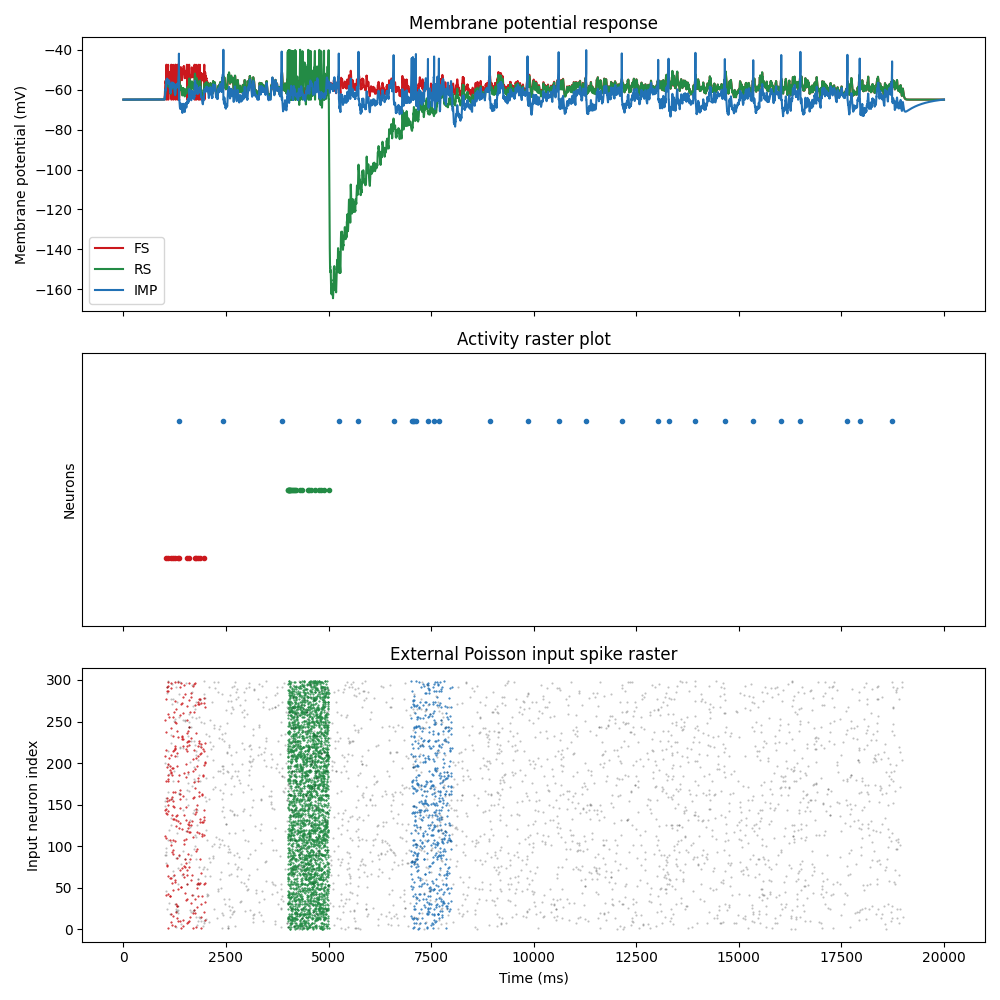

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax[0].plot(mon_FS.t / b2.ms, mon_FS.v[0] / b2.mV, color=color['FS'], label = 'FS')
ax[0].plot(mon_RS.t / b2.ms, mon_RS.v[0] / b2.mV, color=color['RS'], label = 'RS')
ax[0].plot(mon_IMP.t / b2.ms, mon_IMP.v[0] / b2.mV, color=color['IMP'], label = 'IMP')

ax[0].set_ylabel('Membrane potential (mV)')
ax[0].set_title('Membrane potential response')

ax[1].plot(mon_spike_FS.t / b2.ms,  np.zeros(len(mon_spike_FS.t)), '.', color=color['FS'])
ax[1].plot(mon_spike_RS.t / b2.ms,  np.full((len(mon_spike_RS.t)),1), '.', color=color['RS']) # sanity check
ax[1].plot(mon_spike_IMP.t / b2.ms, np.full((len(mon_spike_IMP.t)),2), '.', color=color['IMP']) # sanity check

ax[1].set_yticks([]) 
ax[1].set_ylim(-1,3)
ax[1].set_ylabel('Neurons')
ax[1].set_title('Activity raster plot')

ax[2].plot(mon_Poisson_input_inh.t / b2.ms, mon_Poisson_input_inh.i, '.', color=color['FS'], markersize=1)
ax[2].plot(mon_Poisson_input_exc.t / b2.ms, mon_Poisson_input_exc.i, '.', color=color['RS'], markersize=1)
ax[2].plot(mon_Poisson_input_imp.t / b2.ms, mon_Poisson_input_imp.i, '.', color=color['IMP'], markersize=1)
ax[2].plot(mon_Poisson_input_all.t / b2.ms, mon_Poisson_input_all.i, '.k', alpha = 0.25, markersize=1)

ax[2].set_xlabel('Time (ms)')
ax[2].set_ylabel('Input neuron index')
ax[2].set_title('External Poisson input spike raster')

plt.tight_layout()
ax[0].legend()


In [14]:
stim_duration = sim_duration

n_spikes_FS = mon_spike_FS.count[0]
avg_rate_FS = n_spikes_FS / stim_duration
print(f"Average FS firing rate: {avg_rate_FS / b2.Hz:.2f} Hz")

n_spikes_RS = mon_spike_RS.count[0]
avg_rate_RS = n_spikes_RS / stim_duration
print(f"Average RS firing rate: {avg_rate_RS / b2.Hz:.2f} Hz")

n_spikes_IMP = mon_spike_IMP.count[0]
avg_rate_IMP = n_spikes_IMP / stim_duration
print(f"Average IMP firing rate: {avg_rate_IMP / b2.Hz:.2f} Hz")

Average FS firing rate: 0.70 Hz
Average RS firing rate: 1.15 Hz
Average IMP firing rate: 1.40 Hz


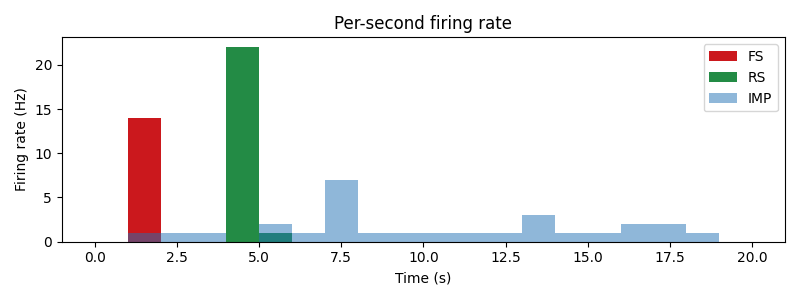

In [15]:
# Convert spike times to seconds
spike_times_FS = mon_spike_FS.t / b2.second
spike_times_RS = mon_spike_RS.t / b2.second
spike_times_IMP = mon_spike_IMP.t / b2.second

# Bin edges: one bin per second
bin_edges = np.arange(0, sim_duration / b2.second + 1, 1.0)

# Histogram: count spikes in each 1-second bin
spikes_per_bin_FS, _ = np.histogram(spike_times_FS, bins=bin_edges)
spikes_per_bin_RS, _ = np.histogram(spike_times_RS, bins=bin_edges)
spikes_per_bin_IMP, _ = np.histogram(spike_times_IMP, bins=bin_edges)

# Firing rate = spikes per second = Hz
firing_rate_per_second_FS = spikes_per_bin_FS / 1.0  
firing_rate_per_second_RS = spikes_per_bin_RS / 1.0  
firing_rate_per_second_IMP = spikes_per_bin_IMP / 1.0  

# Plotting overlapping histograms
plt.figure(figsize=(8, 3))
plt.bar(np.arange(len(firing_rate_per_second_FS)), firing_rate_per_second_FS, width=1.0, align='edge', color = color['FS'], alpha = 1, label='FS')
plt.bar(np.arange(len(firing_rate_per_second_RS)), firing_rate_per_second_RS, width=1.0, align='edge', color = color['RS'], alpha = 1, label='RS')
plt.bar(np.arange(len(firing_rate_per_second_IMP)), firing_rate_per_second_IMP, width=1.0, align='edge', color = color['IMP'], alpha = 0.5, label='IMP')
plt.xlabel('Time (s)')
plt.ylabel('Firing rate (Hz)')
plt.title('Per-second firing rate')
plt.tight_layout()
plt.legend()